In [1]:
import scanpy as sc
import scvi 
import torch
from scvi.external import CellAssign
import pandas as pd
import numpy as np
import scipy
from scipy import sparse

import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR, DATA_DIR, FIGURES_DIR


/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, sys


In [3]:
sc.settings.autosave = True       
sc.settings.figdir = str(FIGURES_DIR / "labelling/d4-lapa")


In [4]:

d4_lapa_dz_clustered = sc.read_h5ad(ANALYSIS_DIR / "data-objects/clustered/clustered_egfDuod_D4_Lapa_DZ.h5ad")

In [5]:
d4_lapa_dz_clustered

## Our 'layers' contains raw 'counts'

AnnData object with n_obs × n_vars = 34969 × 26742
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

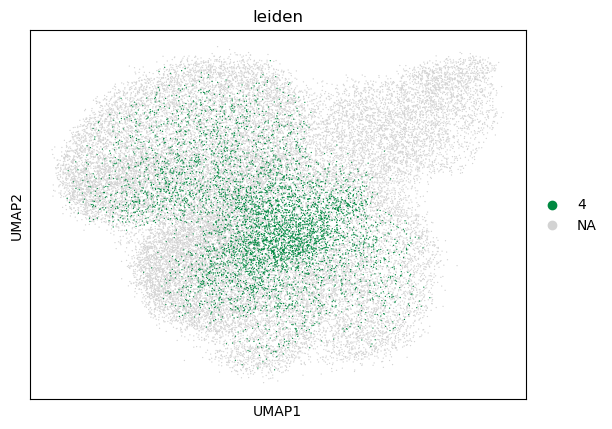

In [6]:
sc.pl.umap(d4_lapa_dz_clustered, color = 'leiden', palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["4"],)

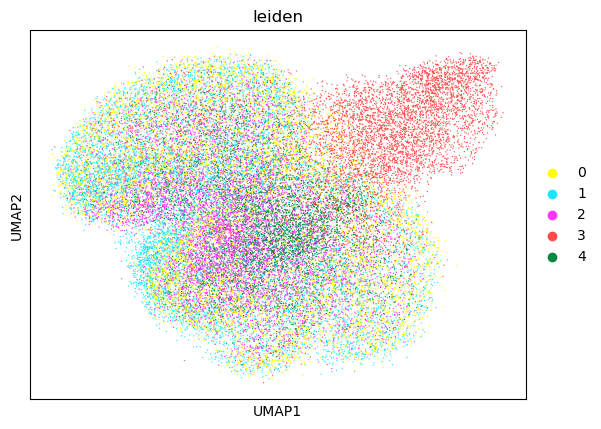

In [7]:
sc.pl.umap(d4_lapa_dz_clustered, color="leiden", save="_d4_lapa_clustered.pdf")


In [8]:
import numpy as np
from scipy.sparse import issparse

def gene_expr_bool(adata, gene, threshold=0.0):
    """
    Return a boolean array (n_cells,) indicating which cells express `gene`
    above `threshold` in adata.X.
    If the gene is missing, returns all False.
    """
    if gene not in adata.var_names:
        print(f"Warning: {gene} not found in var_names; treating as not expressed.")
        return np.zeros(adata.n_obs, dtype=bool)
    
    sub = adata[:, gene]
    X = sub.X
    if issparse(X):
        X = X.toarray()
    X = np.ravel(X)
    return X > threshold

In [9]:
# Make sure leiden is string
d4_lapa_dz_clustered.obs["leiden"] = d4_lapa_dz_clustered.obs["leiden"].astype(str)

# Base label for everything
d4_lapa_dz_clustered.obs["manual_label"] = "PCs"

# Enterocytes: cluster 3
mask_ent_lapa = d4_lapa_dz_clustered.obs["leiden"] == "3"
d4_lapa_dz_clustered.obs.loc[mask_ent_lapa, "manual_label"] = "Enterocytes"

# Inflammed Secretory PCs / Early EECs: cluster 4
mask_inflammed_lapa = d4_lapa_dz_clustered.obs["leiden"] == "4"
d4_lapa_dz_clustered.obs.loc[mask_inflammed_lapa, "manual_label"] = "Inflammed secretory PCs"


mki67_pos_lapa = gene_expr_bool(d4_lapa_dz_clustered, "MKI67")
d4_lapa_dz_clustered.obs.loc[mki67_pos_lapa, "manual_label"] = "Proliferating Progenitor cells"

# Sanity check
print(d4_lapa_dz_clustered.obs["manual_label"].value_counts())

manual_label
PCs                               23328
Enterocytes                        5321
Inflammed secretory PCs            4302
Proliferating Progenitor cells     2018
Name: count, dtype: int64


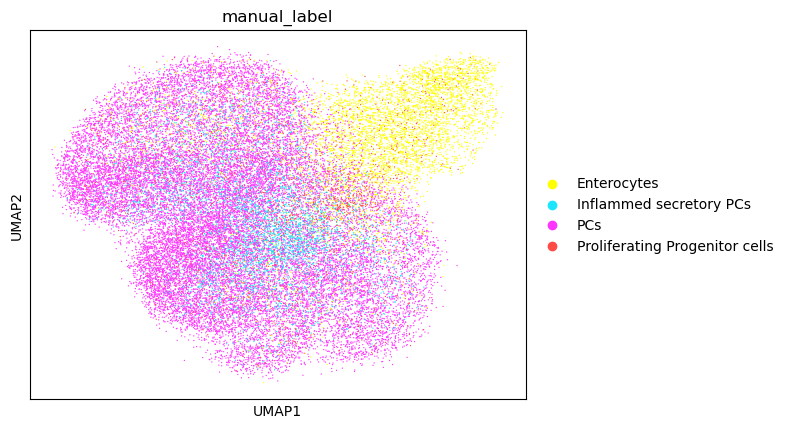

In [10]:
sc.pl.umap(d4_lapa_dz_clustered, color = 'manual_label', palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
)

In [13]:
d4_lapa_dz_clustered.uns["manual_label_colors"]

['#ffff00', '#1ce6ff', '#ff34ff', '#ff4a46']

In [14]:
key = "manual_label"
cats = d4_lapa_dz_clustered.obs[key].cat.categories
cols = d4_lapa_dz_clustered.uns[f"{key}_colors"]

for c, col in zip(cats, cols):
    print(f"{c}: {col}")


Enterocytes: #ffff00
Inflammed secretory PCs: #1ce6ff
PCs: #ff34ff
Proliferating Progenitor cells: #ff4a46


In [11]:
sc.write(str(ANALYSIS_DIR / "data-objects/labelled/d4_lapa_manual_labels.h5ad"), d4_lapa_dz_clustered)